# Interface and contact operations

Two parts that touch are everywhere in a simulation: a joint, a gasket, a pipe split into sectors. This notebook runs the four interface operations on two non-trivial assemblies built from `grid` and a little NumPy warping, so no fixture file is needed:

1. **A curved half-ring in three angular sectors**, meshed once, so the sectors share nodes. `region_adjacency` reports the conforming interfaces between them and `find_interface` extracts one as a facet mesh. `split_interface` then opens it and inserts a layer of zero-thickness cohesive hexahedra.
2. **Two disks meshed independently**, at different resolutions and a few degrees out of parallel. Their nodes do not coincide, so conforming matching finds nothing and the proximity mode is needed. `contact_pairs` then projects the upper disk's contact nodes onto the lower one.

The rendered views use PyVista off-screen and embed the image through matplotlib. If off-screen OpenGL is unavailable, each view falls back to a matplotlib 3-D plot.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

pv.OFF_SCREEN = True
DOC_IMAGES = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "doc", "public", "images"))
SAVE_FIGURE = None  # set to a file stem to also write the figure into the docs


def to_pyvista(mesh):
    with tempfile.NamedTemporaryFile(suffix=".vtu", delete=False) as f:
        path = f.name
    try:
        mp.write(path, mesh, compression=None)
        return pv.read(path)
    finally:
        os.unlink(path)


def show(draw_pyvista, draw_matplotlib, title, stem=None, size=(1100, 760)):
    """Render with PyVista, or with matplotlib if off-screen GL is unavailable."""
    try:
        plotter = pv.Plotter(off_screen=True, window_size=size)
        draw_pyvista(plotter)
        plotter.add_text(title, font_size=11)
        plotter.add_axes()
        image = plotter.screenshot(return_img=True)
        plotter.close()
        fig = plt.figure(figsize=(9, 6))
        plt.imshow(image)
        plt.axis("off")
    except Exception as exc:
        print("PyVista off-screen rendering unavailable; using Matplotlib fallback:", exc)
        fig = plt.figure(figsize=(9, 6))
        ax = fig.add_subplot(111, projection="3d")
        draw_matplotlib(ax)
        ax.set_title(title)
    plt.tight_layout()
    if stem:
        os.makedirs(DOC_IMAGES, exist_ok=True)
        plt.savefig(os.path.join(DOC_IMAGES, stem + ".png"), dpi=120, bbox_inches="tight")
    plt.show()


def facet_triangles(mesh):
    """Triangle/quad corner coordinates of a surface mesh, for the matplotlib fallback."""
    return [mesh.points[c] for block in mesh.cells for c in block.data]

## 1. A curved half-ring, conforming interfaces

`grid` gives a hexahedral lattice in `(r, theta, z)`. Mapping it to polar coordinates bends it into half an annulus: a curved solid whose three angular sectors share nodes along the cutting planes. Each sector becomes a cell `Region`.

In [2]:
nr, nt, nz = 4, 12, 2
lattice = mp.grid([nr, nt, nz], origin=(1.0, 0.0, 0.0), spacing=(0.25, np.pi / nt, 0.3))
p = lattice.points.copy()
r, theta = p[:, 0], p[:, 1]
p[:, 0], p[:, 1] = r * np.cos(theta), r * np.sin(theta)

centroid = p[lattice.cells[0].data].mean(axis=1)
angle = np.arctan2(centroid[:, 1], centroid[:, 0])
sector = np.minimum((angle / (np.pi / 3)).astype(int), 2)

ring = mp.Mesh(
    p,
    lattice.cells,
    regions=[
        mp.Region(f"sector{k}", "cell", np.where(sector == k)[0], dim=3) for k in range(3)
    ],
)
print(f"{len(ring.points)} points, {len(ring.cells[0].data)} hexahedra, "
      f"sectors of {[int((sector == k).sum()) for k in range(3)]} cells")

195 points, 96 hexahedra, sectors of [32, 32, 32] cells


In [3]:
adjacent = mp.region_adjacency(ring, ["sector0", "sector1", "sector2"])
pairs = adjacent.cell_data["interface:measure"][0]
a = adjacent.cell_data["interface:region_a"][0]
b = adjacent.cell_data["interface:region_b"][0]
for ra, rb in sorted(set(zip(a.tolist(), b.tolist()))):
    sel = (a == ra) & (b == rb)
    print(f"sector{ra} | sector{rb}: {sel.sum()} facets, area {pairs[sel].sum():.3f}")

# Each cutting plane is a radial strip of length 1.0 (r from 1.0 to 2.0) and height 0.6.
print("expected area per interface:", 1.0 * 0.6)

sector0 | sector1: 8 facets, area 0.600
sector1 | sector2: 8 facets, area 0.600
expected area per interface: 0.6


meshio warning [interfaces.cpp:818] region_adjacency: source Cell/Side regions are represented by the output adjacency regions; original entries are not copied


Sector 0 and sector 2 never touch, so only two pairs come back, each with the analytic area of a radial strip. `find_interface` extracts one of them as a facet mesh that records the owning cell and local facet of each side, and returns `Side` regions ready for `split_interface`.

In [4]:
interface, report = mp.find_interface(
    ring, "sector0", "sector1", return_report=True
)
print(f"pairs: {report['num_pairs']}, area: {report['area']:.3f}, "
      f"max gap: {report['max_gap']:.1e}, unmatched: {report['unmatched_a']}/{report['unmatched_b']}")
print("cell data:", sorted(interface.cell_data))

split, split_report = mp.split_interface(
    ring, report["side_a"], add_cohesive=True, return_report=True
)
print(f"duplicated points: {split_report['num_duplicated_points']}, "
      f"cohesive cells: {split_report['num_cohesive_cells']}")
print("cell blocks after splitting:", [(c.type, len(c.data)) for c in split.cells])

pairs: 8, area: 0.600, max gap: 0.0e+00, unmatched: 56/56
cell data: ['interface:gap', 'interface:measure', 'interface:parent_cell', 'interface:parent_facet', 'interface:partner_cell', 'interface:partner_facet']
duplicated points: 15, cohesive cells: 8
cell blocks after splitting: [('hexahedron', 96), ('hexahedron', 8)]


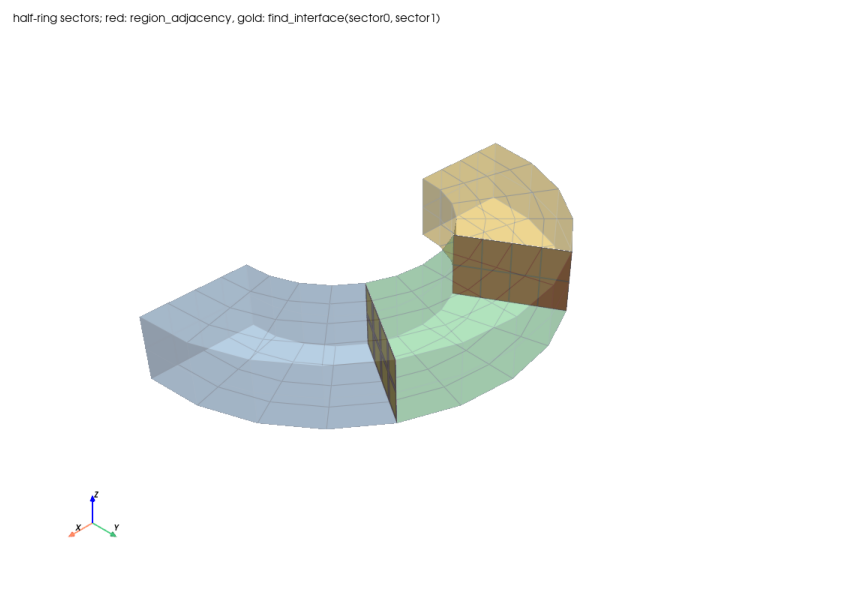

In [5]:
def draw_ring(plotter):
    colours = ["#93c5fd", "#86efac", "#fcd34d"]
    for k, colour in enumerate(colours):
        part = to_pyvista(ring).extract_cells(np.where(sector == k)[0])
        plotter.add_mesh(part, color=colour, opacity=0.35, show_edges=True, edge_color="#475569")
    plotter.add_mesh(to_pyvista(adjacent), color="#dc2626", show_edges=True, edge_color="#7f1d1d", line_width=2, lighting=False)
    plotter.add_mesh(to_pyvista(interface), color="#f59e0b", show_edges=True, edge_color="#7c2d12", line_width=3, lighting=False)
    plotter.camera_position = "iso"


def draw_ring_mpl(ax):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    ax.add_collection3d(Poly3DCollection(facet_triangles(adjacent), facecolor="#dc2626", alpha=0.6, edgecolor="#7f1d1d"))
    ax.add_collection3d(Poly3DCollection(facet_triangles(interface), facecolor="#f59e0b", alpha=0.9, edgecolor="#7c2d12"))
    lo, hi = ring.points.min(axis=0), ring.points.max(axis=0)
    ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(lo[2], hi[2]))
    ax.set_box_aspect(hi - lo)


show(draw_ring, draw_ring_mpl,
     "half-ring sectors; red: region_adjacency, gold: find_interface(sector0, sector1)")

The red strips are the two conforming interfaces reported by `region_adjacency`; the gold one is the pair `find_interface` extracted. After `split_interface` the two sides own separate copies of the nodes on the strip, and a layer of zero-thickness hexahedra bridges them:

cohesive cells: 8  max node offset between traces: 0.0


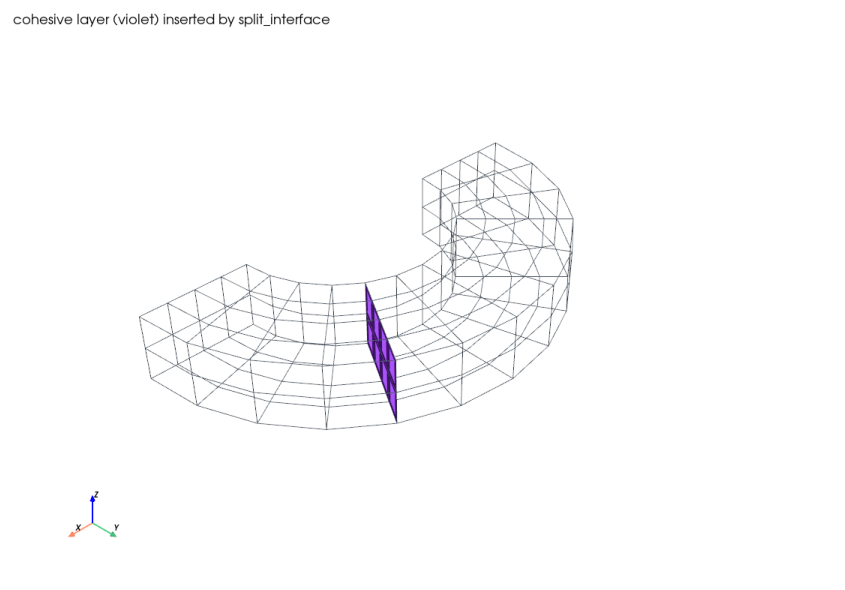

In [6]:
cohesive_block = next(i for i, c in enumerate(split.cells) if c.type == "hexahedron" and i > 0)
solid = mp.Mesh(split.points, [split.cells[0]])
cohesive = mp.Mesh(split.points, [split.cells[cohesive_block]])

# The cohesive layer has no thickness: its cell volume is zero by construction.
coords = split.points[cohesive.cells[0].data]
print("cohesive cells:", len(cohesive.cells[0].data),
      " max node offset between traces:", float(np.abs(coords[:, :4] - coords[:, 4:]).max()))



def draw_split(plotter):
    plotter.add_mesh(to_pyvista(mp.Mesh(split.points, [split.cells[0]])), style="wireframe", color="#64748b", line_width=1)
    plotter.add_mesh(to_pyvista(cohesive), color="#a855f7", show_edges=True, edge_color="#3b0764", line_width=4, lighting=False)
    plotter.camera_position = "iso"


def draw_split_mpl(ax):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    surf = mp.extract_surface(cohesive) if hasattr(mp, "extract_surface") else cohesive
    ax.add_collection3d(Poly3DCollection(facet_triangles(surf), facecolor="#7c3aed", alpha=0.7, edgecolor="#3b0764"))
    lo, hi = split.points.min(axis=0), split.points.max(axis=0)
    ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(lo[2], hi[2]))
    ax.set_box_aspect(hi - lo)


show(draw_split, draw_split_mpl, "cohesive layer (violet) inserted by split_interface")

## 2. Two disks meshed independently, proximity interface

Now the parts are meshed separately: a coarse lower disk and a finer, slightly smaller upper one, tilted by a couple of degrees and floating a few hundredths above it. No node of one coincides with a node of the other, as in a real bolted or press-fit assembly.

In [7]:
def disk(radius, height, nxy, nz):
    """A hexahedral cylinder: a square lattice squeezed onto a disk."""
    g = mp.grid([nxy, nxy, nz], origin=(-1, -1, 0), spacing=(2 / nxy, 2 / nxy, height / nz))
    q = g.points.copy()
    x, y = q[:, 0], q[:, 1]
    q[:, 0] = radius * x * np.sqrt(1 - y**2 / 2)
    q[:, 1] = radius * y * np.sqrt(1 - x**2 / 2)
    return mp.Mesh(q, g.cells)


lower = disk(1.0, 0.5, 8, 3)
upper = mp.transform(disk(0.9, 0.5, 11, 4), rotate=("y", 2.0))
upper = mp.transform(upper, translate=(0.0, 0.0, 0.5 + 0.035))

nlo, nhi = len(lower.cells[0].data), len(upper.cells[0].data)
assembly = mp.merge([lower, upper], source_tag=False)
assembly.regions = [
    mp.Region("lower", "cell", np.arange(nlo), dim=3),
    mp.Region("upper", "cell", np.arange(nlo, nlo + nhi), dim=3),
]
print(f"lower: {nlo} cells, upper: {nhi} cells, {len(assembly.points)} points")

lower: 192 cells, upper: 484 cells, 1044 points


In [8]:
conforming = mp.find_interface(assembly, "lower", "upper", mode="conforming", return_report=True)[1]
print("conforming pairs:", conforming["num_pairs"])

contact, prox = mp.find_interface(
    assembly, "lower", "upper",
    mode="proximity", gap_tolerance=0.1, angle_tolerance=10.0, return_report=True,
)
gap = contact.cell_data["interface:gap"][0]
print(f"proximity pairs: {prox['num_pairs']}, area: {prox['area']:.3f}, "
      f"max gap: {prox['max_gap']:.3f}, gap range: [{gap.min():.3f}, {gap.max():.3f}]")

# The angle tolerance rejects facets whose normals do not oppose within 10 degrees.
tight = mp.find_interface(
    assembly, "lower", "upper",
    mode="proximity", gap_tolerance=0.1, angle_tolerance=1.0, return_report=True,
)[1]
print("pairs with angle_tolerance=1 degree:", tight["num_pairs"])

conforming pairs: 0
proximity pairs: 44, area: 2.401, max gap: 0.057, gap range: [-0.057, -0.006]
pairs with angle_tolerance=1 degree: 0


Conforming matching finds nothing, because no facet of one disk shares its corner nodes with a facet of the other. Proximity matching pairs the lower disk's top facets with the tilted underside of the upper disk, and `interface:gap` records how far apart each pair is. Its sign follows the master side (here the lower disk), so a separation is negative; `contact_pairs` below measures the gap from the slave node and reports the same separation as positive. It is largest on the side the upper disk tilts away from.

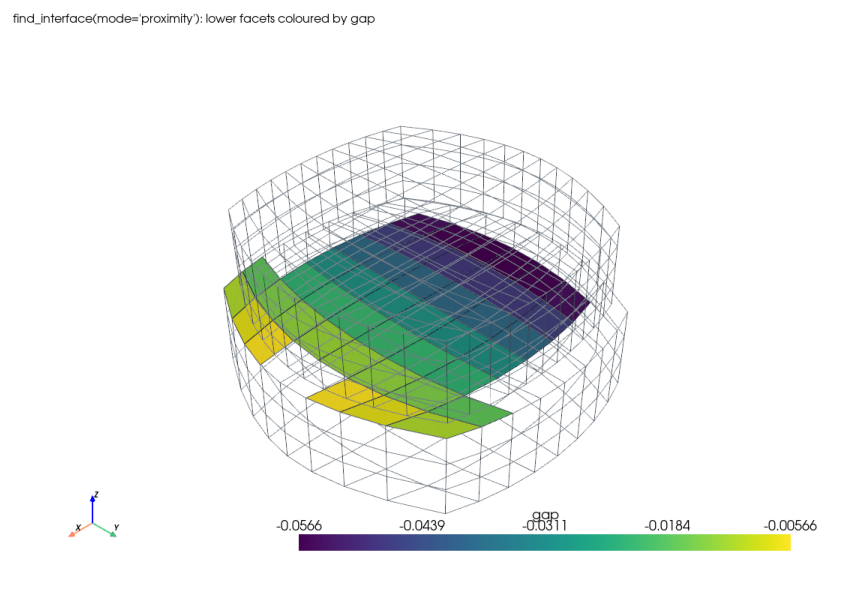

In [9]:
def draw_contact(plotter):
    plotter.add_mesh(to_pyvista(assembly), style="wireframe", color="#94a3b8", line_width=1)
    surf = to_pyvista(contact)
    plotter.add_mesh(surf, scalars="interface:gap", cmap="viridis", show_edges=True,
                     edge_color="#1e293b", scalar_bar_args={"title": "gap"})
    plotter.camera_position = "iso"


def draw_contact_mpl(ax):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    polys = facet_triangles(contact)
    colours = plt.cm.viridis((gap - gap.min()) / max(np.ptp(gap), 1e-12))
    ax.add_collection3d(Poly3DCollection(polys, facecolors=colours, edgecolor="#1e293b"))
    lo, hi = assembly.points.min(axis=0), assembly.points.max(axis=0)
    ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(lo[2], hi[2]))
    ax.set_box_aspect(hi - lo)


show(draw_contact, draw_contact_mpl, "find_interface(mode='proximity'): lower facets coloured by gap")

## 3. Contact pairs: slave nodes onto master facets

A tied or node-to-segment constraint wants, for each slave node, its closest master facet, the position on it, the signed gap and the normal. The slave nodes are a `Point` region: here the underside of the upper disk, picked from the `side_b` region `find_interface` returned.

In [10]:
side_b = prox["side_b"]
# Nodes of the upper disk that lie on a matched facet.
upper_nodes = set()
for cell, _facet in side_b.entries:
    upper_nodes.update(int(n) for n in assembly.cells[0].data[cell])
slave_nodes = np.array(sorted(n for n in upper_nodes if n >= len(lower.points)))
# Keep only the underside: nodes within one layer of the lowest z of the upper disk.
z = assembly.points[slave_nodes, 2]
slave_nodes = slave_nodes[z < z.min() + 0.5 / 4 * 0.5]
assembly.regions.append(mp.Region("slave", "point", slave_nodes))

pairs = mp.contact_pairs(assembly, "slave", "lower", tolerance=0.2)
ok = ~np.isin(pairs["slave_point"], pairs["unmatched"])
print(f"{len(slave_nodes)} slave nodes, {int(ok.sum())} projected onto the lower disk")
print(f"gap range: [{pairs['gap'][ok].min():.3f}, {pairs['gap'][ok].max():.3f}]")

# The projection is orthogonal: the offset to the closest point is along the facet normal.
offset = assembly.points[pairs["slave_point"][ok]] - pairs["closest_point"][ok]
dist = np.linalg.norm(offset, axis=1)
print("max | |offset| - |gap| |:", float(np.abs(dist - np.abs(pairs["gap"][ok])).max()))

114 slave nodes, 114 projected onto the lower disk
gap range: [0.004, 0.061]
max | |offset| - |gap| |: 6.938893903907228e-18


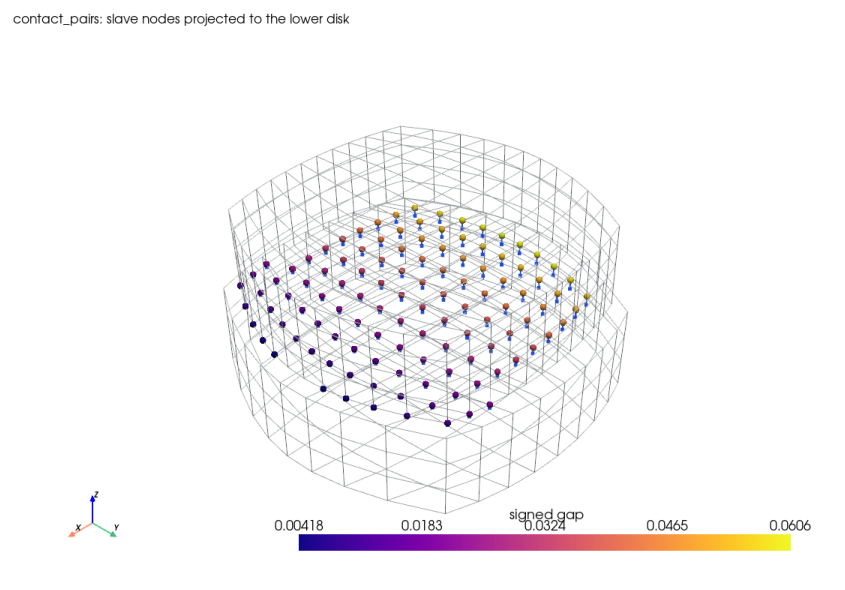

In [11]:
def draw_pairs(plotter):
    plotter.add_mesh(to_pyvista(mp.Mesh(assembly.points, [assembly.cells[0]])), style="wireframe", color="#cbd5e1", line_width=1)
    slave_xyz = assembly.points[pairs["slave_point"][ok]]
    closest = pairs["closest_point"][ok]
    cloud = pv.PolyData(slave_xyz)
    cloud["gap"] = pairs["gap"][ok]
    plotter.add_mesh(cloud, scalars="gap", cmap="plasma", point_size=9, render_points_as_spheres=True,
                     scalar_bar_args={"title": "signed gap"})
    segs = pv.PolyData(np.vstack([slave_xyz, closest]))
    n = len(slave_xyz)
    segs.lines = np.hstack([[2, i, i + n] for i in range(n)])
    plotter.add_mesh(segs, color="#1d4ed8", line_width=2)
    plotter.camera_position = "iso"


def draw_pairs_mpl(ax):
    slave_xyz = assembly.points[pairs["slave_point"][ok]]
    closest = pairs["closest_point"][ok]
    sc = ax.scatter(*slave_xyz.T, c=pairs["gap"][ok], cmap="plasma", s=18)
    for a_, b_ in zip(slave_xyz, closest):
        ax.plot(*np.column_stack([a_, b_]), color="#1d4ed8", linewidth=0.8)
    plt.colorbar(sc, ax=ax, shrink=0.6, label="signed gap")


show(draw_pairs, draw_pairs_mpl, "contact_pairs: slave nodes projected to the lower disk",
     stem="interface_contact")